# 03 — Janela de Atualidade

**Objetivo:** investigar se o tempo decorrido desde a última atualização do
telefone (`registro_data_atualizacao`) impacta a probabilidade de leitura
(`status_disparo == 'read'`). Existe um “prazo de validade” para um telefone
ser considerado *quente*?

Trabalhamos a partir de `disparos_atualidade.parquet`, gerado pelo
notebook `01_preprocessing.ipynb`.

## Roteiro
1. Construir métrica de **alta performance** por telefone (≥ 90% de leituras).
2. Comparar **proporção de telefones de alta performance por ano** de última atualização.
3. Avaliar **decaimento contínuo** com `P(alta performance | dias ≥ x)`.
4. Ajustar uma **árvore de decisão** por sistema para identificar pontos de corte.

## Setup

In [26]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from statsmodels.stats.proportion import proportion_confint

OUT_DIR = Path('../outputs/processed')
TREES_DIR = Path('../outputs/decision_trees')
TREES_DIR.mkdir(parents=True, exist_ok=True)

df_disparos_atualidade = pd.read_parquet(OUT_DIR / 'disparos_atualidade.parquet')
print(f'df_disparos_atualidade: {df_disparos_atualidade.shape}')

df_disparos_atualidade: (637671, 21)


## 1. Métrica de alta performance por telefone
Diferente do notebook 02, aqui o critério de sucesso é **`status == 'read'`**
(definição de *telefone quente*: a mensagem foi efetivamente lida).

In [27]:
LIMIAR_BOM = 0.9

df_tel_read = (
    df_disparos_atualidade
    .assign(read=lambda x: (x['status_disparo'] == 'read').astype(int))
    .groupby(['id_sistema', 'sistema_nome', 'telefone_numero',
              'registro_data_atualizacao', 'dias_desde_atualizacao'])
    .agg(total_envios=('read', 'count'), reads=('read', 'sum'))
    .reset_index()
)
df_tel_read['taxa_read'] = df_tel_read['reads'] / df_tel_read['total_envios']
df_tel_read['alta_perf'] = (df_tel_read['taxa_read'] >= LIMIAR_BOM).astype(int)
df_tel_read['ano'] = df_tel_read['registro_data_atualizacao'].dt.year

df_tel_read.head()

,id_sistema,sistema_nome,telefone_numero,registro_data_atualizacao,dias_desde_atualizacao,total_envios,reads,taxa_read,alta_perf,ano
0,1257277410380486863,Sistema A,10000855312638678978,2024-06-16,679,1,1,1.0,1,2024
1,1257277410380486863,Sistema A,10000909181938355120,2024-05-08,718,1,1,1.0,1,2024
2,1257277410380486863,Sistema A,1000094069898979170,2025-01-03,478,1,0,0.0,0,2025
3,1257277410380486863,Sistema A,10001099649735468021,2025-06-04,326,1,1,1.0,1,2025
4,1257277410380486863,Sistema A,10001204649120744398,2024-09-24,579,1,1,1.0,1,2024


## 2. Proporção de telefones bons por ano de última atualização

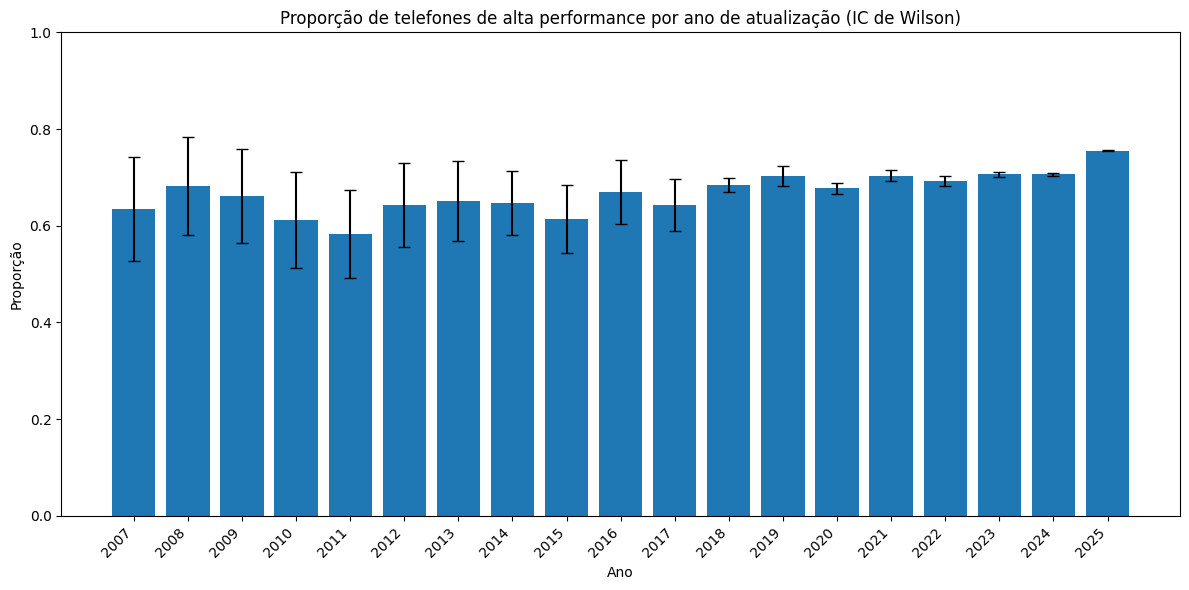

In [34]:
df_year = (
    df_tel_read.groupby('ano')
    .agg(qtd_bons=('alta_perf', 'sum'), total=('alta_perf', 'count'))
    .reset_index()
)
df_year['pct_bons'] = df_year['qtd_bons'] / df_year['total']

lows, highs = zip(*[
    proportion_confint(r['qtd_bons'], r['total'], method='wilson')
    for _, r in df_year.iterrows()
])
df_year['ci_low'], df_year['ci_high'] = lows, highs
df_year['erro'] = df_year['ci_high'] - df_year['pct_bons']

df_year_plot = df_year[df_year['total'] > 50].sort_values('ano')

plt.figure(figsize=(12, 6))
plt.bar(df_year_plot['ano'].astype(str), df_year_plot['pct_bons'],
        yerr=df_year_plot['erro'], capsize=4)
plt.title('Proporção de telefones de alta performance por ano de atualização (IC de Wilson)')
plt.xlabel('Ano')
plt.ylabel('Proporção')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

> Esperava-se observar um decaimento na proporção de telefones de alta performance em anos mais antigos; no entanto, esse padrão não é evidenciado nos dados.

### Detalhe por sistema

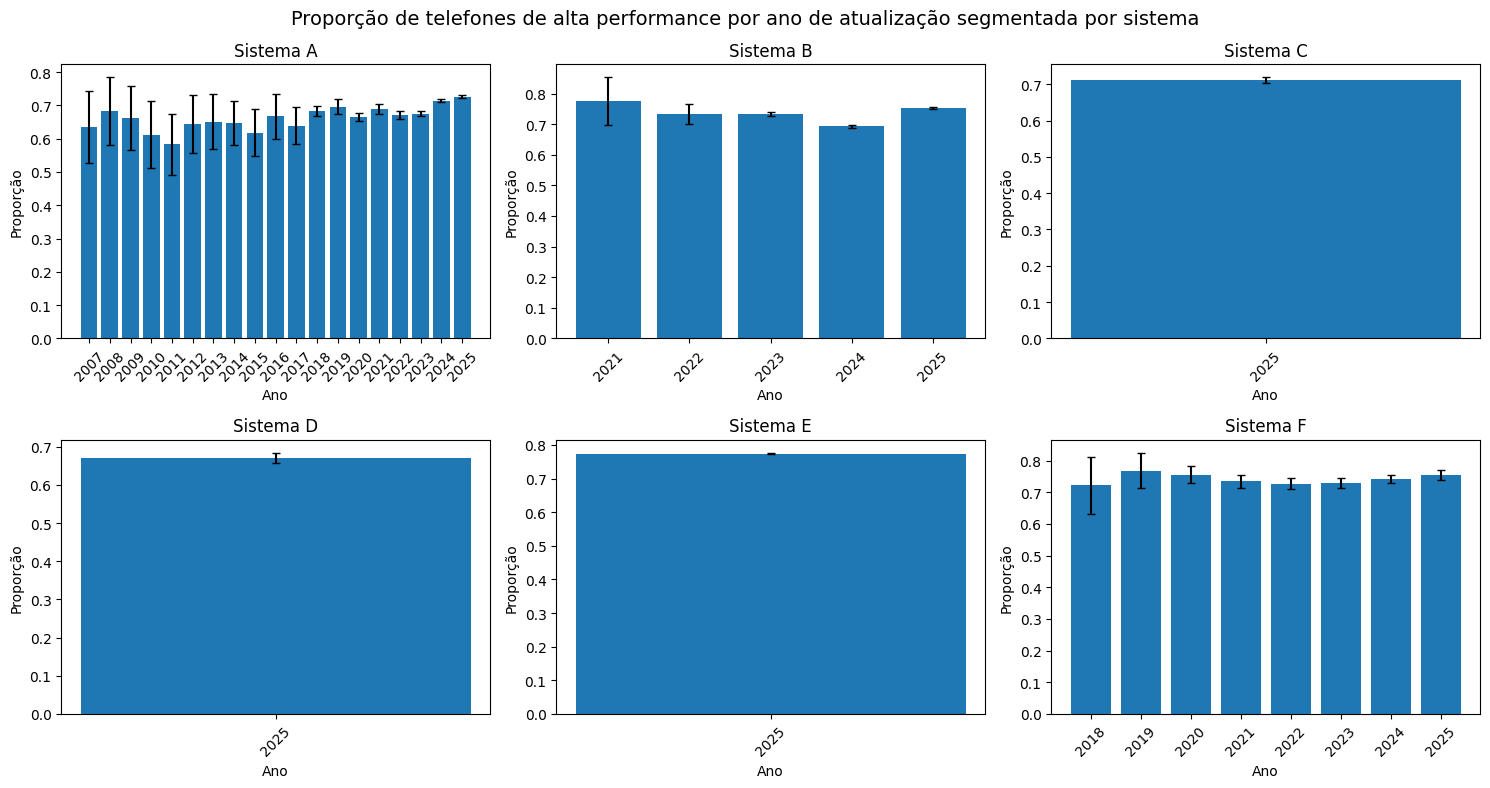

In [38]:
df_year_sys = (
    df_tel_read.groupby(['sistema_nome', 'ano'])
    .agg(qtd_bons=('alta_perf', 'sum'), total=('alta_perf', 'count'))
    .reset_index()
)
df_year_sys['pct_bons'] = df_year_sys['qtd_bons'] / df_year_sys['total']

lows, highs = zip(*[
    proportion_confint(r['qtd_bons'], r['total'], method='wilson')
    for _, r in df_year_sys.iterrows()
])
df_year_sys['ci_low'], df_year_sys['ci_high'] = lows, highs
df_year_sys['erro'] = df_year_sys['ci_high'] - df_year_sys['pct_bons']
df_year_sys = df_year_sys[df_year_sys['total'] > 50]

sistemas = sorted(df_year_sys['sistema_nome'].unique())
cols = 3
rows = math.ceil(len(sistemas) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()
for i, sistema in enumerate(sistemas):
    df_s = df_year_sys[df_year_sys['sistema_nome'] == sistema].sort_values('ano')
    axes[i].bar(df_s['ano'].astype(str), df_s['pct_bons'],
                yerr=df_s['erro'], capsize=3)
    axes[i].set_title(sistema)
    axes[i].set_xlabel('Ano')
    axes[i].set_ylabel('Proporção')
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(sistemas), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Proporção de telefones de alta performance por ano de atualização segmentada por sistema', fontsize=14)
plt.tight_layout()
plt.show()

> A análise dessas métricas segmentada por sistema também não evidencia uma relação clara entre a antiguidade da última atualização e a proporção de telefones de alta performance. Como alternativa, uma abordagem mais promissora é avaliar essa relação em uma granularidade mais fina, como o número de dias desde a última atualização.

## 3. Curva de decaimento `P(alta performance | dias ≥ x)`
Para cada limiar `x` consideramos somente telefones com `dias_desde_atualizacao ≥ x`
e estimamos a fração telefones de alta performance (≥ 90% de taxa de read). Quanto maior o decaimento, menos *quentes* ficam
os telefones antigos.

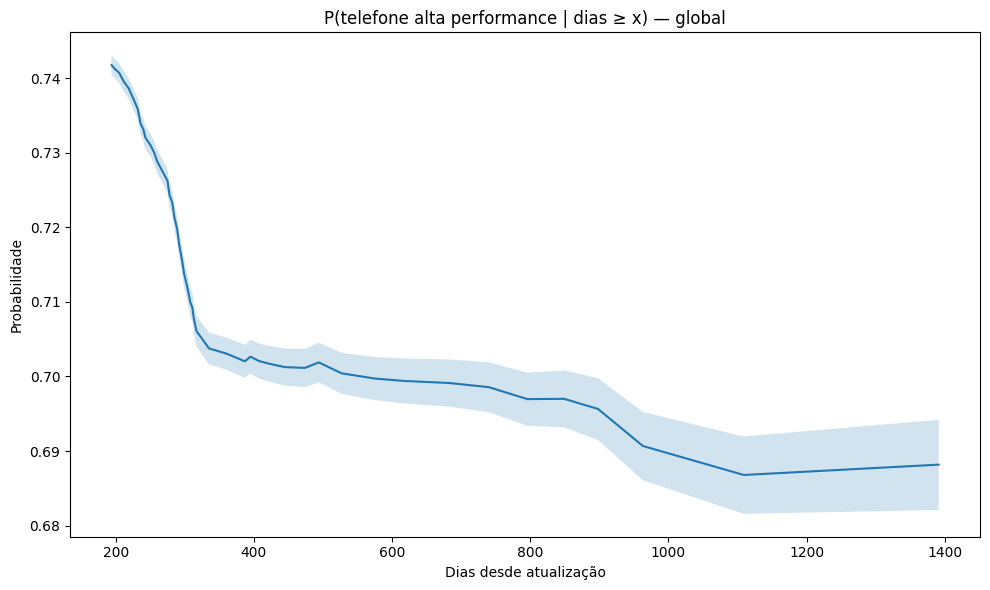

In [39]:
def curva_decay(df: pd.DataFrame, n_pontos: int = 50, n_min: int = 50) -> pd.DataFrame:
    df = df.sort_values('dias_desde_atualizacao')
    valores_x = np.quantile(df['dias_desde_atualizacao'],
                            np.linspace(0.05, 0.95, n_pontos))
    rows = []
    for x in valores_x:
        sub = df[df['dias_desde_atualizacao'] >= x]
        n = len(sub)
        if n < n_min:
            continue
        bons = sub['alta_perf'].sum()
        p = bons / n
        low, high = proportion_confint(bons, n, method='wilson')
        rows.append({'dias': x, 'prob': p, 'ci_low': low, 'ci_high': high, 'n': n})
    return pd.DataFrame(rows)


df_curve_global = curva_decay(df_tel_read)

plt.figure(figsize=(10, 6))
plt.plot(df_curve_global['dias'], df_curve_global['prob'])
plt.fill_between(df_curve_global['dias'],
                 df_curve_global['ci_low'], df_curve_global['ci_high'], alpha=0.2)
plt.title('P(telefone alta performance | dias ≥ x) — global')
plt.xlabel('Dias desde atualização')
plt.ylabel('Probabilidade')
plt.tight_layout()
plt.show()

> A curva de probabilidade cumulativa sugere que, à medida que aumenta o número de dias desde a última atualização (dias ≥ x), há uma redução na probabilidade de um telefone apresentar alta performance.
No entanto, permanece a questão: esse padrão é consistente entre todos os sistemas?

### Curva de decaimento por sistema

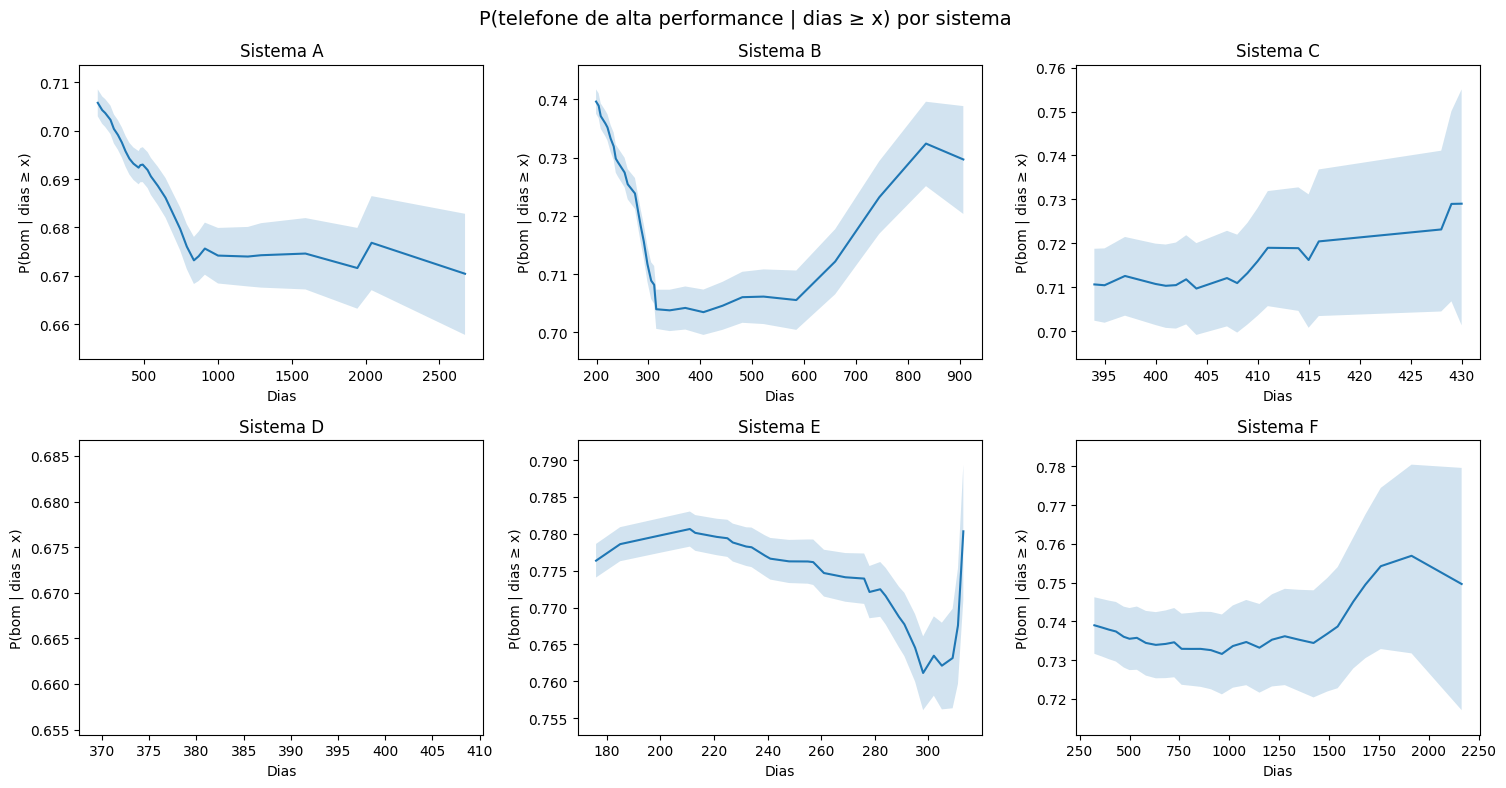

In [31]:
curvas = []
for sistema in sorted(df_tel_read['sistema_nome'].unique()):
    df_sys = df_tel_read[df_tel_read['sistema_nome'] == sistema]
    df_curve = curva_decay(df_sys, n_pontos=30, n_min=200)
    df_curve['sistema_nome'] = sistema
    curvas.append(df_curve)
df_curve_sys = pd.concat(curvas, ignore_index=True)

sistemas = sorted(df_curve_sys['sistema_nome'].unique())
cols = 3
rows = math.ceil(len(sistemas) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()
for i, sistema in enumerate(sistemas):
    df_s = df_curve_sys[df_curve_sys['sistema_nome'] == sistema]
    axes[i].plot(df_s['dias'], df_s['prob'])
    axes[i].fill_between(df_s['dias'], df_s['ci_low'], df_s['ci_high'], alpha=0.2)
    axes[i].set_title(sistema)
    axes[i].set_xlabel('Dias')
    axes[i].set_ylabel('P(bom | dias ≥ x)')
    if not df_s.empty:
        ymin, ymax = df_s['ci_low'].min(), df_s['ci_high'].max()
        pad = (ymax - ymin) * 0.1 if ymax > ymin else 0.01
        axes[i].set_ylim(ymin - pad, ymax + pad)
for j in range(len(sistemas), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'P(telefone de alta performance | dias ≥ x) por sistema',
    fontsize=14
)

plt.tight_layout()
plt.show()

> Ao analisar os resultados por sistema, observa-se que o padrão global não se mantém de forma consistente, indicando possível influência desproporcional de sistemas com maior volume de dados. Enquanto o sistema A e, em menor grau, o sistema E apresentam o comportamento esperado, com queda na probabilidade de alta performance à medida que aumenta o tempo desde a última atualização, outros sistemas exibem padrões distintos, incluindo aumento dessa probabilidade para telefones mais antigos. Diante dessa heterogeneidade, uma abordagem mais adequada é definir pontos de corte específicos por sistema.

## 4. Árvores de decisão por sistema
Identificam, automaticamente, o(s) ponto(s) de corte em `dias_desde_atualizacao`
que melhor separam telefones de alta performance dos demais.
*Sistema D* é descartado por volume insuficiente.

Resultados salvos na pasta: `outputs/decision_trees/` 

In [41]:
SISTEMAS_IGNORAR = {'Sistema D'}
arvores = {}

for sistema in sorted(df_tel_read['sistema_nome'].unique()):
    if sistema in SISTEMAS_IGNORAR:
        continue
    df_sys = (
        df_tel_read[df_tel_read['sistema_nome'] == sistema]
        .dropna(subset=['dias_desde_atualizacao', 'alta_perf'])
    )
    X = df_sys[['dias_desde_atualizacao']]
    y = df_sys['alta_perf']

    clf = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X, y)
    arvores[sistema] = clf

    plt.figure(figsize=(8, 5))
    plot_tree(clf, feature_names=['dias_desde_atualizacao'],
              class_names=['baixa_perf', 'alta_perf'], filled=True)
    plt.title(f'Árvore de Decisão — {sistema}')
    plt.savefig(TREES_DIR / f'arvore_{sistema.replace(" ", "_")}.png',
                dpi=300, bbox_inches='tight')
    plt.close()
print(f'Árvores treinadas: {list(arvores)}')

Árvores treinadas: ['Sistema A', 'Sistema B', 'Sistema C', 'Sistema E', 'Sistema F']


### Extração de regras
Para cada folha extraímos a probabilidade estimada de alta performance e as regras (pontos de corte).

In [43]:
def extrair_regras(clf, sistema: str) -> pd.DataFrame:
    tree = clf.tree_
    regras = []

    def recurse(node, condicoes):
        if tree.children_left[node] == tree.children_right[node]:
            valores = tree.value[node][0]
            total = valores.sum()
            prob_alta = valores[1] / total if total else 0

            regras.append({
                'sistema': sistema,
                'regra': ' AND '.join(condicoes) or '(sem condição)',
                'prob_alta_perf': prob_alta
            })
            return

        threshold = tree.threshold[node]

        recurse(tree.children_left[node], condicoes + [f'dias <= {threshold:.0f}'])
        recurse(tree.children_right[node], condicoes + [f'dias > {threshold:.0f}'])

    recurse(0, [])
    
    df = pd.DataFrame(regras)
    

    return df.sort_values('prob_alta_perf', ascending=False)

df_regras = pd.concat([
    extrair_regras(clf, s) 
    for s, clf in arvores.items()
])

df_regras = df_regras.sort_values(
    ['sistema', 'prob_alta_perf'], 
    ascending=[True, False]
)

# adiciona id_sistema a partir do mapeamento presente nos dados
map_id = df_tel_read[['sistema_nome', 'id_sistema']].drop_duplicates()
df_regras = df_regras.merge(
    map_id, left_on='sistema', right_on='sistema_nome', how='left'
).drop(columns=['sistema_nome'])

df_regras = df_regras[['id_sistema', 'sistema', 'regra', 'prob_alta_perf']]

df_regras.to_csv(TREES_DIR /'df_regras_atualidade.csv', index=False)
display(df_regras)

,id_sistema,sistema,regra,prob_alta_perf
0,1257277410380486863,Sistema A,dias <= 826,0.723402
1,1257277410380486863,Sistema A,dias > 826,0.673030
2,3094574413675758272,Sistema B,dias <= 314,0.766901
3,3094574413675758272,Sistema B,dias > 314,0.703959
4,4458959843028638627,Sistema C,dias > 428,0.728960
5,4458959843028638627,Sistema C,dias <= 428,0.707701
6,13742676811738960007,Sistema E,dias > 208,0.780622
7,13742676811738960007,Sistema E,dias <= 208,0.731121
8,18313131241423355789,Sistema F,dias <= 604,0.754106
9,18313131241423355789,Sistema F,dias > 604,0.733606


## Conclusão

A análise investigou se o tempo decorrido desde a última atualização do telefone impacta a probabilidade de leitura, utilizando três abordagens: proporção de telefones de alta performance por ano, curva de decaimento contínuo e árvores de decisão por sistema. A análise agregada por ano não evidenciou diferenças relevantes na proporção de telefones de alta performance.

Ao reduzir a granularidade para o número de dias desde a última atualização, a curva de probabilidade cumulativa passa a indicar um possível padrão de decaimento, com menor probabilidade de alta performance para telefones mais antigos. No entanto, ao segmentar por sistema, observa-se que esse comportamento não é consistente, com diferenças relevantes entre as fontes.

Diante dessa heterogeneidade, a definição de uma regra única baseada em tempo se mostra inadequada. A abordagem mais robusta é adotar pontos de corte específicos por sistema, refletindo diferentes “prazos de validade” e permitindo uma priorização mais adequada dos contatos, o que foi realizado por meio de árvores de decisão ao final do notebook.